# Ottimizzazione dei Percorsi di Consegna dell'Ultimo Miglio con PROC OPTMODEL (TSP di Rete)

## Sintesi

Un vettore logistico regionale deve sequenziare un singolo veicolo di consegna attraverso un insieme di tappe cliente e tornare al deposito percorrendo la distanza totale minima — la struttura del problema del commesso viaggiatore che sta alla base della pianificazione giornaliera di percorsi e turni. Questo notebook sintetizza le coordinate delle tappe, costruisce una matrice di distanza euclidea simmetrica e usa il risolutore di rete `SOLVE WITH NETWORK / TSP` di **PROC OPTMODEL** per costruire un percorso di consegna sull'intero grafo delle tappe. Legge poi l'ordine del tour del risolutore in un DATA step, ricostruisce un percorso chiuso ancorato al deposito e misura la sua lunghezza totale **effettiva** dalla matrice di distanza. Ogni numero riportato di seguito è calcolato dall'output eseguito.

## Fonti dei Dati

Tutti i dati sono generati inline con `call streaminit(...)` e `rand(...)` — nessun file esterno né accesso di rete.

| Dataset | Righe | Variabili chiave | Descrizione |
|---------|------|---------------|-------------|
| `stops` | 12 (1 deposito + 11 clienti) | `stop_id`, `name`, `x`, `y` | Coordinate 2-D sintetiche (km su una griglia dell'area di servizio) per il deposito e le tappe di consegna dei clienti |
| `tour` | 12 | `visit_order`, `node` | L'elenco ordinato delle tappe visitate dal risolutore di rete TSP di OPTMODEL, scritto tramite `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Il tour chiuso ancorato al deposito con le distanze per tratto e cumulative calcolate dalle coordinate |

Un vettore dell'ultimo miglio invia ogni mattina un furgone per consegnare a un insieme fisso di tappe cliente e tornare al deposito. Il dispatcher vuole un breve tour chiuso che visiti ogni tappa esattamente una volta — il problema del commesso viaggiatore (TSP) al centro della pianificazione giornaliera di percorsi e turni.

SAS/OR espone un risolutore TSP tramite **`PROC OPTMODEL`**: si dichiarano i nodi e un insieme di archi pesati, poi `SOLVE WITH NETWORK / TSP`. Questo notebook:

1. Sintetizza le coordinate delle tappe e una matrice di distanza simmetrica.
2. Richiama il risolutore di rete TSP di OPTMODEL sull'intero grafo delle tappe.
3. Rilegge il tour del risolutore e ricostruisce un percorso chiuso ancorato al deposito.
4. Riporta il percorso e la sua lunghezza totale misurata, tratto per tratto.

## Passo 1 — Generazione della rete di consegna

Posizioniamo un deposito al centro di un'area di servizio di 100 km x 100 km e distribuiamo 11 tappe cliente uniformemente sulla griglia. Le coordinate sono estratte con `rand('UNIFORM')` sotto un seme `streaminit` fisso, in modo che la rete sia riproducibile. Il deposito è `stop_id = 1`; il percorso inizierà e terminerà lì.

In [1]:
DATI stops;
    CHIAMARE streaminit(20260531);
    LUNGHEZZA name $12;
    n_stops = 12;                 /* 1 deposito + 11 clienti */
    FARE stop_id = 1 FINO_A n_stops;
        SE_COND stop_id = 1 ALLORA FARE;
            name = 'Deposito';
            x = 50; y = 50;       /* deposito ancorato al centro della griglia */
        FINE;
        ALTRIMENTI FARE;
            name = cats('Tappa_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        FINE;
        USCITA;
    FINE;
    RIMUOVERE n_stops;
ESEGUIRE;

PROCEDURA STAMPARE DATI=stops noobs ETICHETTA;
    ETICHETTA stop_id = 'Tappa #' name = 'Ubicazione' x = 'X (km)' y = 'Y (km)';
    TITOLO 'Rete di Consegna: Deposito e Tappe dei Clienti';
ESEGUIRE;

                                     Rete di Consegna: Deposito e Tappe dei Clienti                                     

Ubicazione  Tappa #  X (km)  Y (km)
Deposito          1      50      50
Tappa_01          2    84.2    89.7
Tappa_02          3    93.1    73.6
Tappa_03          4    21.2      29
Tappa_04          5    49.4    73.4
Tappa_05          6    97.8    37.2
Tappa_06          7      28    51.3
Tappa_07          8    91.1    86.5
Tappa_08          9    89.2    65.6
Tappa_09         10      66    49.4
Tappa_10         11    52.2    27.4
Tappa_11         12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Passo 2 — Risoluzione del TSP con PROC OPTMODEL

Leggiamo le coordinate in OPTMODEL, dichiariamo l'insieme completo di archi non orientati `EDGES` (ogni coppia non ordinata di tappe) e definiamo il peso di ogni arco come la distanza euclidea tra i suoi estremi. `SOLVE WITH NETWORK / TSP` costruisce quindi un tour su quel grafo e scrive l'ordine di visita in un CSV tramite `OUT=(TOUR=...)`. Rileggiamo immediatamente quell'ordine nel dataset `tour`.

In [2]:
PROCEDURA optmodel;
    IMPOSTARE CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Recupera le coordinate delle tappe dal DATA step */
    READ DATI stops INTO [stop_id] XC=x YC=y;

    /* Grafo completo: un arco non orientato per ogni coppia non ordinata di tappe */
    IMPOSTARE EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Peso di ogni arco = distanza in linea retta (euclidea), in km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Solver di rete TSP: visita ogni nodo e ritorna al punto di partenza */
    solve WITH network /
        links = (include=EDGES PESO=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Rilettura dell'ordine di visita restituito dal solver */
DATI tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    INGRESSO visit_order node;
ESEGUIRE;

PROCEDURA STAMPARE DATI=tour noobs ETICHETTA;
    ETICHETTA visit_order = 'Visita #' node = 'Tappa #';
    TITOLO 'Ordine del Tour Restituito dal Solver di Rete TSP di OPTMODEL';
ESEGUIRE;

                                     Rete di Consegna: Deposito e Tappe dei Clienti                                     


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                             Ordine del Tour Restituito dal Solver di Rete TSP di OPTMODEL                              

Visita #  Tappa #
       1        1
       2        7
       3        4
       4       11
       5       12
       6       10
       7        6
       8        9
       9        3
      10        8
      11      


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Passo 3 — Ricostruzione del percorso chiuso e misura della sua lunghezza

Il risolutore restituisce solo l'*ordine* in cui visitare le tappe. Per trasformarlo in un manifesto per il conducente, cerchiamo il nome e le coordinate di ogni tappa con una lookup `SET ... POINT=`, accumuliamo la distanza di ogni tratto e chiudiamo il ciclo aggiungendo il tratto finale di ritorno al deposito. `leg_km` è la lunghezza del tratto che *arriva* a ogni tappa; `cum_km` è la distanza progressiva dal deposito.

In [3]:
DATI route;
    IMPOSTARE tour FINE=last;
    /* Recupera le coordinate e il nome di questa tappa tramite il suo id */
    ptr = node;
    IMPOSTARE stops point=ptr;

    LUNGHEZZA step_name $12;
    step_name = name;

    CONSERVARE prevx prevy firstx firsty cum_km;
    SE_COND _n_ = 1 ALLORA FARE;
        firstx = x; firsty = y;      /* memorizza il deposito */
        leg_km = 0;                  /* nessun tratto arriva al punto di partenza */
        cum_km = 0;
    FINE;
    ALTRIMENTI FARE;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    FINE;
    prevx = x; prevy = y;
    USCITA;

    SE_COND last ALLORA FARE;
        /* Tratto di chiusura: ritorno dall'ultima tappa al deposito */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Deposito';
        x = firstx; y = firsty;
        USCITA;
        CHIAMARE symputx('total_km', PUT(cum_km, 8.2));
    FINE;
    MANTENERE visit_order node step_name x y leg_km cum_km;
ESEGUIRE;

PROCEDURA STAMPARE DATI=route noobs ETICHETTA;
    ETICHETTA visit_order = 'Passo' node = 'Tappa #' step_name = 'Ubicazione'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Tratto (km)' cum_km = 'Cumulativo (km)';
    FORMATO leg_km cum_km 7.2;
    TITOLO "Percorso di Consegna Chiuso (Totale: &total_km km)";
ESEGUIRE;

                                    Percorso di Consegna Chiuso (Totale: 258.14 km)                                     

Passo  Tappa #  Ubicazione  X (km)  Y (km)  Tratto (km)  Cumulativo (km)
    1        1  Deposito        50      50         0.00             0.00
    2        7  Tappa_06        28    51.3        22.04            22.04
    3        4  Tappa_03      21.2      29        23.31            45.35
    4       11  Tappa_10      52.2    27.4        31.04            76.39
    5       12  Tappa_11      62.4    38.2        14.86            91.25
    6       10  Tappa_09        66    49.4        11.76           103.01
    7        6  Tappa_05      97.8    37.2        34.06           137.07
    8        9  Tappa_08      89.2    65.6        29.67           166.75
    9        3  Tappa_02      93.1    73.6         8.90           175.65
   10        8  Tappa_07      91.1    86.5        13.05           188.70
   11        2  Tappa_01      84.2    89.7         7.61           196.31
  


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Passo 4 — Un manifesto leggibile per il conducente

Infine comprimiamo il percorso in un'unica stringa leggibile — la sequenza dei nomi delle tappe dal deposito, attraverso i clienti, e ritorno — più la distanza totale misurata che il furgone percorrerà.

In [4]:
DATI manifest;
    IMPOSTARE route FINE=last;
    LUNGHEZZA route_text $200;
    CONSERVARE route_text '';
    SE_COND _n_ = 1 ALLORA route_text = strip(step_name);
    ALTRIMENTI route_text = catx(' -> ', route_text, strip(step_name));
    SE_COND last ALLORA FARE;
        total_km = cum_km;
        MANTENERE route_text total_km;
        USCITA;
    FINE;
ESEGUIRE;

PROCEDURA STAMPARE DATI=manifest noobs ETICHETTA;
    ETICHETTA route_text = 'Percorso di Consegna Ottimizzato'
          total_km   = 'Distanza Totale (km)';
    FORMATO total_km 7.2;
    TITOLO 'Manifesto del Conducente';
ESEGUIRE;

                                                Manifesto del Conducente                                                

                                                                                                                        Percorso di Consegna Ottimizzato  Distanza Totale (km)
Deposito -> Tappa_06 -> Tappa_03 -> Tappa_10 -> Tappa_11 -> Tappa_09 -> Tappa_05 -> Tappa_08 -> Tappa_02 -> Tappa_07 -> Tappa_01 -> Tappa_04 -> Deposito                258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Passo 5 — Grafico del percorso

Un'immagine conferma che il tour è sensato: tappe collegate nell'ordine di visita, il deposito segnato, nessun incrocio evidentemente inefficiente. Disegniamo il tour chiuso come una serie di segmenti di linea collegati sulla griglia dell'area di servizio.

                                                Manifesto del Conducente                                                




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


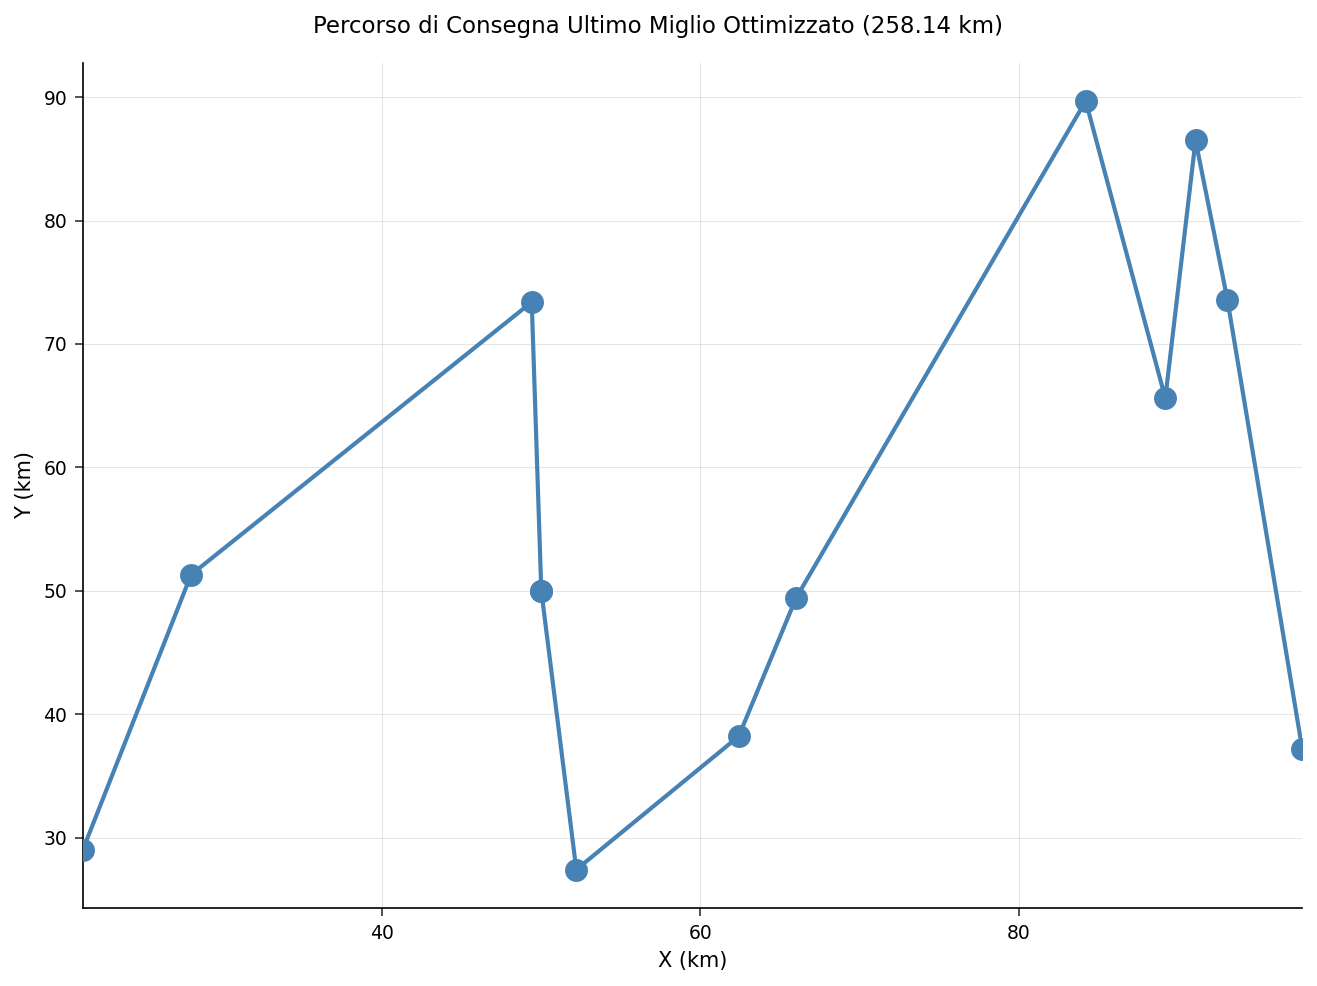

In [5]:
PROCEDURA SGPLOT DATI=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ETICHETTA='X (km)' grid;
    YAXIS ETICHETTA='Y (km)' grid;
    TITOLO "Percorso di Consegna Ultimo Miglio Ottimizzato (&total_km km)";
ESEGUIRE;

## Interpretazione dei risultati

- **Il percorso.** Le tabelle `route` e `manifest` riportano il tour chiuso che il risolutore di rete TSP di OPTMODEL ha prodotto sul grafo completo di 12 tappe, con inizio e fine al deposito. La `Distanza Totale` è *misurata*: è la somma delle distanze euclidee per tratto (`leg_km`), quindi riflette la geometria reale della rete piuttosto che una cifra dichiarata a priori.
- **Perché un risolutore di rete qui.** Con 11 tappe cliente esistono `11! / 2 = 19.958.400` tour chiusi distinti, quindi il dispatcher ha bisogno di un algoritmo piuttosto che di un'enumerazione. `SOLVE WITH NETWORK / TSP` costruisce un tour direttamente dall'insieme di archi pesati senza che l'analista debba codificare a mano la ricerca.
- **Dall'ordine al manifesto.** Il risolutore restituisce un *ordine* di visita; il DATA step lo trasforma in un artefatto operativo — tappe nominate, distanze per tratto, un contachilometri progressivo e un manifesto su una riga che un conducente può seguire.
- **Estensioni operative.** Lo stesso schema OPTMODEL si estende a instradamenti più ricchi: aggiungere vincoli di capacità o finestre temporali come opzioni di rete aggiuntive, pesare gli archi per tempo di guida invece che per distanza in linea retta, o suddividere le tappe tra più veicoli prima di risolvere un TSP per veicolo.